<a href="https://colab.research.google.com/github/sriram-dsl/computer-vision/blob/main/naano_VLM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import math, random
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import numpy as np

##Variables

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMG_SIZE = 32
EMBED_DIM = 64
ATTENTION_HEADS = 16
BATCH_SIZE = 32 if torch.cuda.is_available() else 16
EPOCHS = 100
LR = 3e-4
TEMPERATURE = 0.05

#Synthetic Dataset Properties

In [3]:
colors = ['red', 'green', 'blue', 'yellow', 'purple', 'orange', 'pink', 'brown', 'gray']
shapes = ['square', 'circle', 'triangle']
positions = ['left', 'center', 'right', 'top', 'bottom', 'top-left', 'top-right', 'bottom-left', 'bottom-right']

## Drawing image shapes

In [4]:
def get_color_rgb(color_name):
    color_map = {
        'red': (255, 0, 0),
        'green': (0, 128, 0),
        'blue': (0, 0, 255),
        'yellow': (255, 255, 0),
        'purple': (128, 0, 128),
        'orange': (255, 165, 0),
        'pink': (255, 192, 203),
        'brown': (165, 42, 42),
        'gray': (128, 128, 128),
        'white': (255, 255, 255),
        'black': (0, 0, 0)
    }
    return color_map.get(color_name.lower(), (0, 0, 0)) # Default to black if not found

In [5]:
def draw_sample(color_name, shape, position, img_size = IMG_SIZE):
  img = Image.new('RGB', (img_size, img_size))
  draw = ImageDraw.Draw(img)

  # Set white background
  draw.rectangle([0, 0, img_size, img_size], fill='white')

  margin_border = 3 # The border on all sides
  inner_area_start = margin_border
  inner_area_end = img_size - margin_border

  # Shape dimensions based on user's request: w/2 - margin(6)
  # Assuming 'w' refers to img_size
  shape_dim = img_size // 2 - 6 # Use integer division for pixel perfect sizing

  # Calculate bounding box for the shape based on position
  x0, y0 = 0, 0
  if position == 'center':
      x0 = (img_size - shape_dim) // 2
      y0 = (img_size - shape_dim) // 2
  elif position == 'left':
      x0 = inner_area_start
      y0 = (img_size - shape_dim) // 2
  elif position == 'right':
      x0 = inner_area_end - shape_dim
      y0 = (img_size - shape_dim) // 2
  elif position == 'top':
      x0 = (img_size - shape_dim) // 2
      y0 = inner_area_start
  elif position == 'bottom':
      x0 = (img_size - shape_dim) // 2
      y0 = inner_area_end - shape_dim
  elif position == 'top-left':
      x0 = inner_area_start
      y0 = inner_area_start
  elif position == 'top-right':
      x0 = inner_area_end - shape_dim
      y0 = inner_area_start
  elif position == 'bottom-left':
      x0 = inner_area_start
      y0 = inner_area_end - shape_dim
  elif position == 'bottom-right':
      x0 = inner_area_end - shape_dim
      y0 = inner_area_end - shape_dim

  x1 = x0 + shape_dim
  y1 = y0 + shape_dim

  fill_color = get_color_rgb(color_name)

  if shape == 'square':
      draw.rectangle([x0, y0, x1, y1], fill=fill_color)
  elif shape == 'circle':
      draw.ellipse([x0, y0, x1, y1], fill=fill_color)
  elif shape == 'triangle':
      # For a triangle, we define three points.
      # Let's make it an upward-pointing equilateral triangle inscribed within the bounding box.
      mid_x = x0 + shape_dim // 2
      draw.polygon([(mid_x, y0), (x0, y1), (x1, y1)], fill=fill_color)

  return img

### Demonstration of `draw_sample` function

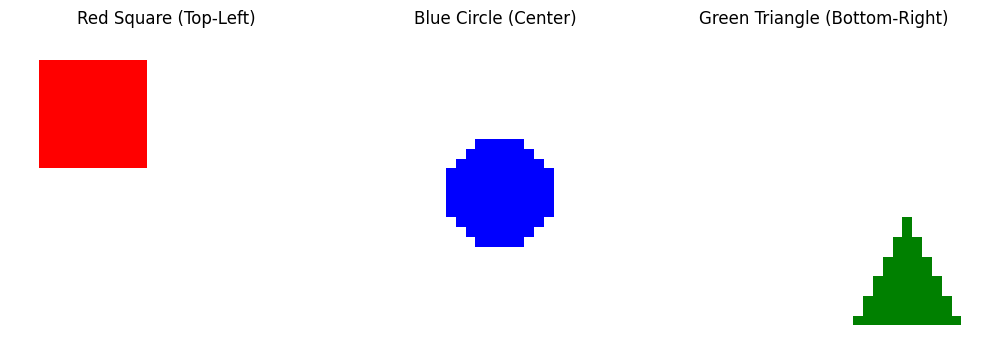

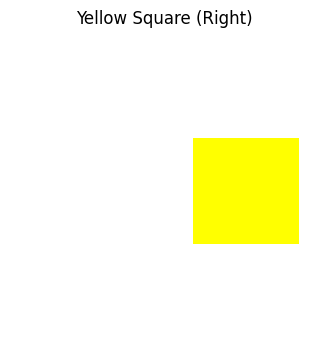

In [6]:
# Generate and display a few sample images
fig, axes = plt.subplots(1, 3, figsize=(10, 4))

# Example 1: Red Square at Top-Left
img1 = draw_sample('red', 'square', 'top-left')
axes[0].imshow(img1)
axes[0].set_title('Red Square (Top-Left)')
axes[0].axis('off')

# Example 2: Blue Circle at Center
img2 = draw_sample('blue', 'circle', 'center')
axes[1].imshow(img2)
axes[1].set_title('Blue Circle (Center)')
axes[1].axis('off')

# Example 3: Green Triangle at Bottom-Right
img3 = draw_sample('green', 'triangle', 'bottom-right')
axes[2].imshow(img3)
axes[2].set_title('Green Triangle (Bottom-Right)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

# Example 4: Yellow Square at Right
img4 = draw_sample('yellow', 'square', 'right')
plt.figure(figsize=(4,4))
plt.imshow(img4)
plt.title('Yellow Square (Right)')
plt.axis('off')
plt.show()

# Dataset creation class

In [7]:
class ShapeDataset():
  def __init__(self):
    self.images = []
    self.captions = []

    for c in colors:
      for s in shapes:
        for p in positions:
          img = draw_sample(c, s, p)
          cap = f"{c} {s} {p}"

          # Add .copy() to ensure the NumPy array is writable
          self.images.append(torch.from_numpy(np.asarray(img).copy()).permute(2,0,1).float()/255.0)
          self.captions.append(cap)
    self.vocab, self.word2idx = self.build_vocab(self.captions)

  def build_vocab(self, texts):
    words = sorted({w for t in texts for w in t.split()})
    vocab = ['[CLS]'] + words
    w2i = {w:i for i,w in enumerate(vocab)}
    return vocab, w2i

  def encode_text(self, text):
    toks = [self.word2idx['[CLS]']] + [self.word2idx[w] for w in text.split()]
    return torch.tensor(toks, dtype=torch.long)

  def __getitem__(self, idx):
    return self.images[idx], self.encode_text(self.captions[idx]), self.captions[idx]

  def __len__(self):
    return len(self.images)

In [8]:
full_dataset = ShapeDataset()
print(f"Total length of the dataset : {len(full_dataset)}")
print(f"Total vocab size : {len(full_dataset.vocab)}")
print(f"Vocab : {full_dataset.vocab}")

Total length of the dataset : 243
Total vocab size : 22
Vocab : ['[CLS]', 'blue', 'bottom', 'bottom-left', 'bottom-right', 'brown', 'center', 'circle', 'gray', 'green', 'left', 'orange', 'pink', 'purple', 'red', 'right', 'square', 'top', 'top-left', 'top-right', 'triangle', 'yellow']


In [9]:
train_size = int(0.8*len(full_dataset))
val_size = int(len(full_dataset)) - train_size
train_ds, val_ds = torch.utils.data.random_split(full_dataset, [train_size, val_size])

## DataLoader

In [10]:
train_loader = DataLoader(train_ds, batch_size = BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

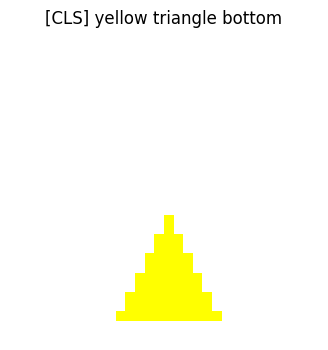

Decoded Caption: [CLS] yellow triangle bottom


In [11]:
imgs, encoded_caps, cap = next(iter(train_loader))
idx = random.randint(0, len(imgs)-1)
img = (imgs[idx].permute(1,2,0).numpy()*255).astype(np.uint8)

# decode captions
caption_tokens = encoded_caps[idx].tolist()
caption = ' '.join(full_dataset.vocab[token] for token in caption_tokens if token in range(len(full_dataset.vocab)))

# Display the image and caption
plt.figure(figsize=(4,4))
plt.imshow(img)
plt.title(caption)
plt.axis('off')
plt.show()

print(f"Decoded Caption: {caption}")

## Image Encoder

In [12]:
class ImageEncoder(nn.Module) :
  def __init__(self, embed_dim=EMBED_DIM) :
    super().__init__()
    self.convolutions = nn.Sequential(
        # convolution inputs = (input channel size, output channel size(no.of filters), kernal size), stride, pading size
        nn.Conv2d(3,32,3,2,1),
        nn.ReLU(),
        nn.Conv2d(32,64,3,2,1),
        nn.ReLU(),
        nn.Conv2d(64,128,3,2,1),
        nn.ReLU(),
        nn.Conv2d(128,256,3,2,1),
        nn.ReLU(),
    )
    self.projection = nn.Linear(256, embed_dim)
    self.layernorm1 = nn.LayerNorm(embed_dim)

  def forward(self, x) :
    x = self.convolutions(x)
    x = x.mean(dim=[2,3])
    x = self.projection(x)
    x = F.normalize(self.layernorm1(x), dim=-1)
    return x

# Text Encoder

In [13]:
class TextEncoder(nn.Module) :
  def __init__(self, embed_dim= EMBED_DIM, num_heads = ATTENTION_HEADS, vocab_size = 0, context_window = 4) :
    super().__init__()
    self.token_embedding = nn.Embedding(vocab_size, embed_dim)
    self.position_embedding = nn.Embedding(context_window, embed_dim) # Fixed typo
    self.mha = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True) # Added batch_first
    self.projection = nn.Linear(embed_dim, embed_dim)
    self.norm = nn.LayerNorm(embed_dim)

  def forward(self, toks) :
    N,L = toks.shape
    position_emb_ids = torch.arange(L, device=toks.device).unsqueeze(0).expand(N,L) # Fixed typo
    position_embedding_vectors = self.position_embedding(position_emb_ids)
    token_embedding_vectors = self.token_embedding(toks)
    x = token_embedding_vectors + position_embedding_vectors # (N, L, embed_dim)
    attn_output, _ = self.mha(x, x, x) # mha returns output and attention weights
    x = attn_output[:, 0, :] # Take the CLS token embedding (first token)
    x = self.projection(x)
    x = F.normalize(self.norm(x), dim=-1)
    return x

In [14]:
def clip_loss(img_emb, txt_emb, temp=TEMPERATURE) :
  logits = img_emb @ txt_emb.T / temp
  targets = torch.arange(img_emb.size(0), device=img_emb.device)
  loss_i = F.cross_entropy(logits, targets)
  loss_t = F.cross_entropy(logits.T, targets)
  return((loss_i + loss_t ) /2.0)

In [15]:
img_enc = ImageEncoder().to(device)
# Pass vocab_size and context_window. Max caption length is 4: '[CLS] color shape position'
txt_enc = TextEncoder(vocab_size=len(full_dataset.vocab), context_window=4).to(device)
params = list(img_enc.parameters()) + list(txt_enc.parameters()) # Fixed txt_env to txt_enc
optimizer = torch.optim.AdamW(params, lr=LR)

In [16]:
def show_image(t, title= None) :
  img = (t.permute(1,2,0).cpu().numpy() * 255).astype('uint8')
  plt.figure(figsize=(4,4))
  plt.imshow(img)
  if title is not None:
    plt.title(title)
  plt.axis('off')
  plt.show()

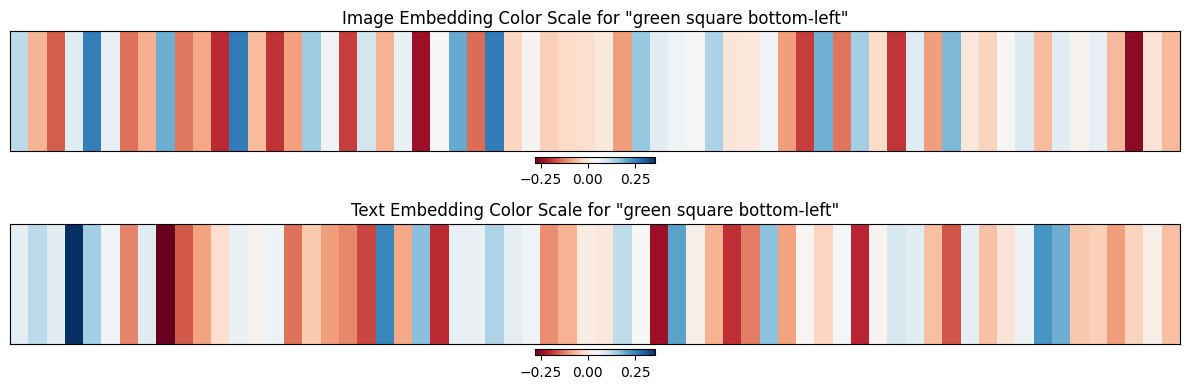

Pre-train Image Embedding (first 5 dims): [ 0.12144767 -0.07172534 -0.15510194  0.07663067  0.2592326 ]
Pre-train Text Embedding (first 5 dims): [0.06734259 0.12083756 0.07201367 0.35819232 0.14746623]
Cosine Similarity (Pre-Training) between image and text embedding: -0.0412


In [17]:
img_enc.eval()
txt_enc.eval()

with torch.no_grad() :
  random_idx = random.randrange(len(full_dataset))
  sample_img, sample_toks, sample_cap = full_dataset[random_idx]
  sample_img = sample_img.unsqueeze(0).to(device)
  sample_toks = sample_toks.unsqueeze(0).to(device)
  pre_train_img_emb = img_enc(sample_img).squeeze(0).cpu().numpy()
  pre_train_txt_emb = txt_enc(sample_toks).squeeze(0).cpu().numpy()

  # Ensure both embeddings are treated with the same scale for consistent color mapping
  vmin = min(pre_train_img_emb.min(), pre_train_txt_emb.min())
  vmax = max(pre_train_img_emb.max(), pre_train_txt_emb.max())

  fig, axes = plt.subplots(2, 1, figsize=(12, 4)) # Two subplots vertically stacked

  # Image Embedding Visualization
  im1 = axes[0].imshow(pre_train_img_emb.reshape(1, -1), cmap='RdBu', aspect='auto', vmin=vmin, vmax=vmax)
  axes[0].set_title(f'Image Embedding Color Scale for "{sample_cap}"')
  axes[0].set_xticks([]) # Hide x-axis ticks
  axes[0].set_yticks([]) # Hide y-axis ticks
  plt.colorbar(im1, ax=axes[0], orientation='horizontal', fraction=0.046, pad=0.04) # Add colorbar

  # Text Embedding Visualization
  im2 = axes[1].imshow(pre_train_txt_emb.reshape(1, -1), cmap='RdBu', aspect='auto', vmin=vmin, vmax=vmax)
  axes[1].set_title(f'Text Embedding Color Scale for "{sample_cap}"')
  axes[1].set_xticks([]) # Hide x-axis ticks
  axes[1].set_yticks([]) # Hide y-axis ticks
  plt.colorbar(im2, ax=axes[1], orientation='horizontal', fraction=0.046, pad=0.04) # Add colorbar

  plt.tight_layout()
  plt.show()

  print(f"Pre-train Image Embedding (first 5 dims): {pre_train_img_emb[:5]}")
  print(f"Pre-train Text Embedding (first 5 dims): {pre_train_txt_emb[:5]}")

  # Calculate and print cosine similarity between pre-trained embeddings
  similarity_pre_train = np.dot(pre_train_img_emb, pre_train_txt_emb) / (np.linalg.norm(pre_train_img_emb) * np.linalg.norm(pre_train_txt_emb))
  print(f"Cosine Similarity (Pre-Training) between image and text embedding: {similarity_pre_train:.4f}")

#Training

In [18]:
best_eval = float('inf') # Fixed typo

for epoch in range(1, EPOCHS+1):
  img_enc.train()
  txt_enc.train()
  total_train_loss = 0.0 # Renamed for clarity

  for imgs, toks, _ in train_loader: # Fixed 'ings' to 'imgs'
    imgs = imgs.to(device)
    toks = toks.to(device)
    optimizer.zero_grad(set_to_none =True) # Fixed 'opt' to 'optimizer'
    ie = img_enc(imgs)
    te = txt_enc(toks)
    loss = clip_loss(ie, te)
    loss.backward()
    optimizer.step() # Fixed 'opt' to 'optimizer'
    total_train_loss += loss.item() * imgs.size(0) # Fixed ++ and corrected accumulation

  train_loss = total_train_loss / len(train_ds) # Calculate average loss over the dataset size

  img_enc.eval()
  txt_enc.eval()
  with torch.no_grad() :
    total_val_loss, num_val_samples = 0.0, 0 # Renamed for clarity and fixed 'n'
    for imgs, toks, _ in val_loader : # Fixed 'imags' to 'imgs'
      imgs = imgs.to(device)
      toks = toks.to(device)
      batch_loss = clip_loss(img_enc(imgs), txt_enc(toks)).item()
      total_val_loss += batch_loss * imgs.size(0) # Corrected accumulation
      num_val_samples += imgs.size(0) # Fixed n + img.size(0)
    val_loss = total_val_loss / num_val_samples # Calculate average loss over the dataset size

  print(f"EPOCH {epoch:02d} | train {train_loss:.4f} | val : {val_loss:.4f}") # Added formatting

  best_eval = min(best_eval, val_loss) # Fixed typo

EPOCH 01 | train 3.4958 | val : 3.2060
EPOCH 02 | train 3.3717 | val : 3.1226
EPOCH 03 | train 3.2265 | val : 2.8284
EPOCH 04 | train 2.7580 | val : 2.3761
EPOCH 05 | train 1.9631 | val : 1.6793
EPOCH 06 | train 1.3532 | val : 1.0259
EPOCH 07 | train 0.9798 | val : 0.8018
EPOCH 08 | train 0.7844 | val : 0.7776
EPOCH 09 | train 0.6365 | val : 0.7647
EPOCH 10 | train 0.6387 | val : 0.5667
EPOCH 11 | train 0.6278 | val : 0.5309
EPOCH 12 | train 0.4797 | val : 0.4649
EPOCH 13 | train 0.3783 | val : 0.4033
EPOCH 14 | train 0.3229 | val : 0.3356
EPOCH 15 | train 0.2282 | val : 0.2573
EPOCH 16 | train 0.1801 | val : 0.2192
EPOCH 17 | train 0.1554 | val : 0.1780
EPOCH 18 | train 0.1267 | val : 0.1683
EPOCH 19 | train 0.1555 | val : 0.1680
EPOCH 20 | train 0.1148 | val : 0.1275
EPOCH 21 | train 0.0825 | val : 0.1139
EPOCH 22 | train 0.0780 | val : 0.1144
EPOCH 23 | train 0.0821 | val : 0.1050
EPOCH 24 | train 0.0621 | val : 0.1048
EPOCH 25 | train 0.0657 | val : 0.0999
EPOCH 26 | train 0.0541 |

### Visualize Embeddings and Test Model

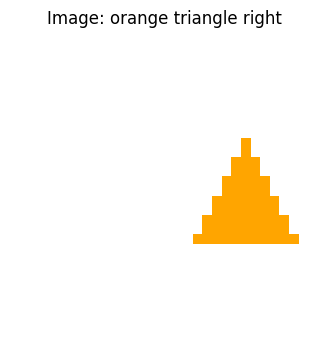

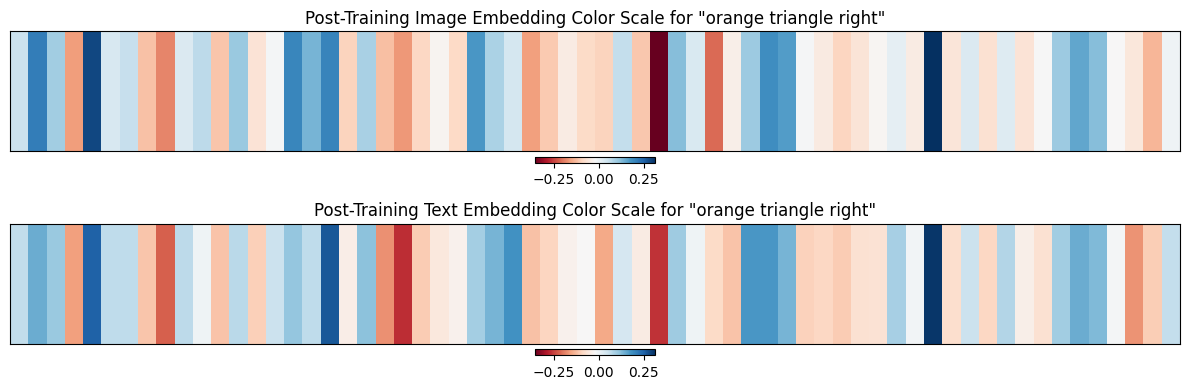

Image Embedding (first 5 dims): [ 0.05053133  0.21057732  0.09526873 -0.16185814  0.28459355]
Text Embedding (first 5 dims): [ 0.06108126  0.14530739  0.10295989 -0.15989964  0.24997704]
Cosine Similarity between image and text embedding: 0.9074


In [19]:
img_enc.eval()
txt_enc.eval()

with torch.no_grad():
  # Get embeddings for all images and captions in the validation set
  val_images = []
  val_captions = []
  for img, _, cap_text in val_ds:
    val_images.append(img.to(device))
    val_captions.append(txt_enc(full_dataset.encode_text(cap_text).unsqueeze(0).to(device)).squeeze(0))

  val_image_embeddings = torch.stack([img_enc(img.unsqueeze(0)).squeeze(0) for img in val_images])
  val_text_embeddings = torch.stack(val_captions)

  # Choose a random sample from the validation set to visualize
  random_idx = random.randrange(len(val_ds))
  sample_img, sample_toks, sample_cap_text = val_ds[random_idx]

  sample_img_tensor = sample_img.unsqueeze(0).to(device)
  sample_toks_tensor = sample_toks.unsqueeze(0).to(device)

  # Get embeddings from the trained model
  post_train_img_emb = img_enc(sample_img_tensor).squeeze(0).cpu().numpy()
  post_train_txt_emb = txt_enc(sample_toks_tensor).squeeze(0).cpu().numpy()

  # Display the image and its corresponding text embedding
  show_image(sample_img, title=f"Image: {sample_cap_text}")

  # Ensure both embeddings are treated with the same scale for consistent color mapping
  vmin = min(post_train_img_emb.min(), post_train_txt_emb.min())
  vmax = max(post_train_img_emb.max(), post_train_txt_emb.max())

  fig, axes = plt.subplots(2, 1, figsize=(12, 4)) # Two subplots vertically stacked

  # Image Embedding Visualization
  im1 = axes[0].imshow(post_train_img_emb.reshape(1, -1), cmap='RdBu', aspect='auto', vmin=vmin, vmax=vmax)
  axes[0].set_title(f'Post-Training Image Embedding Color Scale for "{sample_cap_text}"')
  axes[0].set_xticks([]) # Hide x-axis ticks
  axes[0].set_yticks([]) # Hide y-axis ticks
  plt.colorbar(im1, ax=axes[0], orientation='horizontal', fraction=0.046, pad=0.04) # Add colorbar

  # Text Embedding Visualization
  im2 = axes[1].imshow(post_train_txt_emb.reshape(1, -1), cmap='RdBu', aspect='auto', vmin=vmin, vmax=vmax)
  axes[1].set_title(f'Post-Training Text Embedding Color Scale for "{sample_cap_text}"')
  axes[1].set_xticks([]) # Hide x-axis ticks
  axes[1].set_yticks([]) # Hide y-axis ticks
  plt.colorbar(im2, ax=axes[1], orientation='horizontal', fraction=0.046, pad=0.04) # Add colorbar

  plt.tight_layout()
  plt.show()

  print(f"Image Embedding (first 5 dims): {post_train_img_emb[:5]}")
  print(f"Text Embedding (first 5 dims): {post_train_txt_emb[:5]}")

  # Calculate cosine similarity between the image and text embeddings
  similarity = torch.dot(torch.from_numpy(post_train_img_emb), torch.from_numpy(post_train_txt_emb)).item()
  print(f"Cosine Similarity between image and text embedding: {similarity:.4f}")

### Image-to-Text Retrieval

Let's test the model's ability to retrieve the most relevant images for a given text query.

Query: red square center
Top 5 most similar images:


/tmp/ipykernel_8495/7724462.py:9: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4480.)
  similarities = val_image_embeddings @ query_text_embedding.T


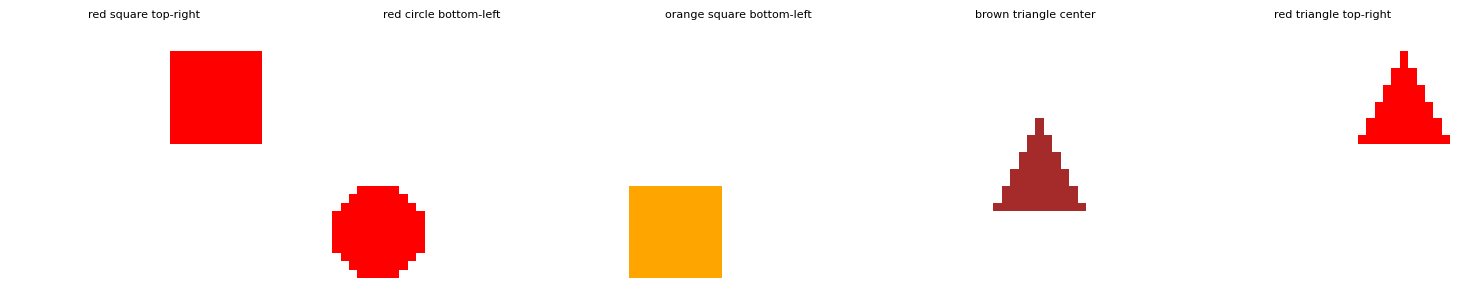

In [20]:
img_enc.eval()
txt_enc.eval()

with torch.no_grad():
  query_text = "red square center" # You can change this query
  encoded_query = full_dataset.encode_text(query_text).unsqueeze(0).to(device)
  query_text_embedding = txt_enc(encoded_query).squeeze(0)

  similarities = val_image_embeddings @ query_text_embedding.T
  top_k_indices = torch.topk(similarities, k=5).indices.cpu().numpy()

  print(f"Query: {query_text}")
  print("Top 5 most similar images:")

  fig, axes = plt.subplots(1, 5, figsize=(15, 3))
  for i, idx in enumerate(top_k_indices):
    img_tensor = val_ds[idx][0]
    caption = val_ds[idx][2]
    axes[i].imshow((img_tensor.permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8))
    axes[i].set_title(caption, fontsize=8)
    axes[i].axis('off')
  plt.tight_layout()
  plt.show()

### Text-to-Image Retrieval

Let's test the model's ability to retrieve the most relevant text captions for a given image.

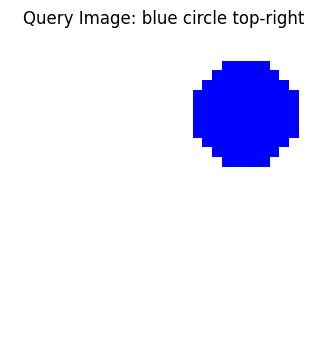

Top 5 most similar captions:
1. blue circle top-right (Similarity: 0.9201)
2. purple circle top (Similarity: 0.6140)
3. blue circle top-left (Similarity: 0.5988)
4. blue square top (Similarity: 0.5555)
5. brown circle top-right (Similarity: 0.5387)


In [21]:
img_enc.eval()
txt_enc.eval()

with torch.no_grad():
  # Choose a random image from the validation set as a query
  random_img_idx = random.randrange(len(val_ds))
  query_image, _, original_caption = val_ds[random_img_idx]
  query_image_tensor = query_image.unsqueeze(0).to(device)
  query_image_embedding = img_enc(query_image_tensor).squeeze(0)

  # Display the query image
  show_image(query_image, title=f"Query Image: {original_caption}")

  similarities = val_text_embeddings @ query_image_embedding.T
  top_k_indices = torch.topk(similarities, k=5).indices.cpu().numpy()

  print("Top 5 most similar captions:")
  for i, idx in enumerate(top_k_indices):
    print(f"{i+1}. {val_ds[idx][2]} (Similarity: {similarities[idx]:.4f})")